# Data cleaning and EDA

Team 16 - Gunn Madan, Harini Mohan

Loads the raw NOAA dataset, filters to Chicago / NYC / LA, keeps TMAX/TMIN/PRCP, builds seasonal + rolling features, and runs the EDA plots used in the report.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import data_cleaning as dc
import feature_engineering as fe
import visualize as vz

RAW = os.path.abspath(os.path.join('..', 'data', 'OriginalWeatherDataset.csv'))
DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
FIG_DIR = os.path.abspath(os.path.join('..', 'outputs', 'figures'))

## Load raw dataset

In [2]:
raw = dc.load_raw(RAW)
print('Rows:', len(raw))
print('Columns:', len(raw.columns))
raw[['STATION', 'NAME', 'DATE', 'TMAX', 'TMIN', 'PRCP']].head()

Rows: 11190
Columns: 50


,STATION,NAME,DATE,TMAX,TMIN,PRCP
0,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2016-01-01,31.0,19.0,0.0
1,USW00094728,"NY CITY CENTRAL PARK, NY US",2016-01-01,42.0,34.0,0.0
2,USW00093134,"LOS ANGELES DOWNTOWN USC, CA US",2016-01-01,64.0,43.0,0.0
3,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2016-01-02,32.0,20.0,0.0
4,USW00094728,"NY CITY CENTRAL PARK, NY US",2016-01-02,40.0,32.0,0.0


## Clean + normalize city names

In [3]:
clean = dc.clean(raw)
print('Rows after clean:', len(clean))
print(clean['CITY'].value_counts())
clean.head()

Rows after clean: 11188
CITY
Chicago    3730
NYC        3730
LA         3728
Name: count, dtype: int64


,DATE,CITY,TMAX,TMIN,PRCP
0,2016-01-01,Chicago,31.0,19.0,0.0
1,2016-01-02,Chicago,32.0,20.0,0.0
2,2016-01-03,Chicago,29.0,22.0,0.0
3,2016-01-04,Chicago,31.0,22.0,0.0
4,2016-01-05,Chicago,33.0,17.0,0.0


## Feature engineering

- `month`, `dayofyear` for seasonality
- `temp_range = TMAX - TMIN`
- 7 day rolling mean / std (per city, so NYC values dont bleed into LA)

In [4]:
feat = fe.add_features(clean)
dc.save(feat, os.path.join(DATA_DIR, 'clean_weather_data.csv'))
feat.head()

,DATE,CITY,TMAX,TMIN,PRCP,month,dayofyear,temp_range,rolling_mean,rolling_std,rolling_mean_tmin,rolling_mean_prcp
0,2016-01-07,Chicago,41.0,34.0,0.01,1,7,7.0,33.285714,4.029652,22.142857,0.001429
1,2016-01-08,Chicago,42.0,36.0,0.19,1,8,6.0,34.857143,5.014265,24.571429,0.028571
2,2016-01-09,Chicago,40.0,23.0,0.27,1,9,17.0,36.000000,5.163978,25.000000,0.067143
3,2016-01-10,Chicago,23.0,2.0,0.00,1,10,21.0,35.142857,6.768273,22.142857,0.067143
4,2016-01-11,Chicago,24.0,-1.0,0.11,1,11,25.0,34.142857,7.904188,18.857143,0.082857


## EDA plots

In [5]:
vz.plot_temp_distribution(feat, FIG_DIR)
vz.plot_monthly_avg(feat, FIG_DIR)
vz.plot_correlation(feat, FIG_DIR)
print('Saved EDA figures to', FIG_DIR)

/sessions/dreamy-optimistic-cray/mnt/outputs/Team16-WeatherAnomalyDetection/src/visualize.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='CITY', y='TMAX', ax=ax,


Saved EDA figures to /sessions/dreamy-optimistic-cray/mnt/outputs/Team16-WeatherAnomalyDetection/outputs/figures


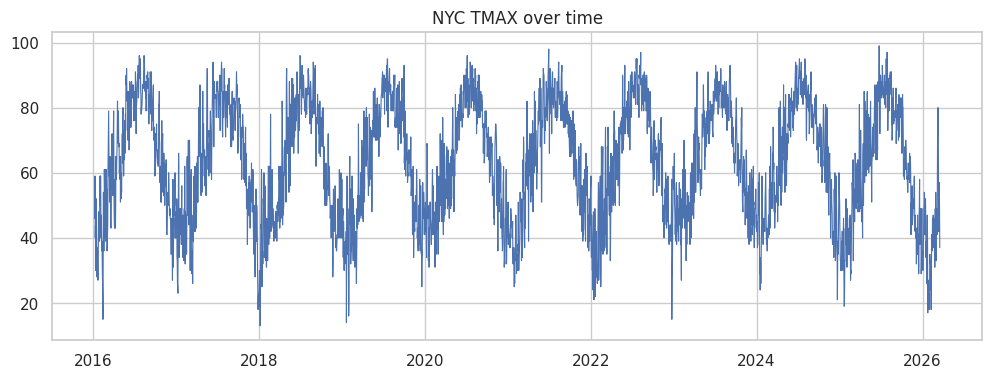

In [6]:
# quick visual sanity check - NYC TMAX over time
nyc = feat[feat['CITY'] == 'NYC']
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nyc['DATE'], nyc['TMAX'], linewidth=0.8)
ax.set_title('NYC TMAX over time')
plt.show()